# Mapping lines to neighborhoods

A subway line "serves" a neighborhood in a fuzzy way — riders walk to
the nearest station, and the station belongs to whichever line stops
there. To ask whether service quality tracks neighborhood income, we
first need a defensible way to assign each line a service area, and
each service area a population profile.

The approach: for each line, take all the stations it serves; buffer
each station by 800 meters (about a ten-minute walk); union the buffers
into a service polygon; intersect with census tracts; population-weight
the demographic averages.

In [1]:
import sys
sys.path.append("../code")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from utils import MTA_COLORS, MAIN_LINES

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../output/figures")

stops = pd.read_csv(RAW / "gtfs" / "stops.txt")
routes = pd.read_csv(RAW / "gtfs" / "routes.txt")
trips = pd.read_csv(RAW / "gtfs" / "trips.txt")
stop_times = pd.read_csv(RAW / "gtfs" / "stop_times.txt")

tracts = gpd.read_file(RAW / "nyct2020")

print("stops:", stops.shape, "| columns:", list(stops.columns))
print("routes:", routes.shape, "| columns:", list(routes.columns))
print("trips:", trips.shape, "| columns:", list(trips.columns))
print("stop_times:", stop_times.shape, "| columns:", list(stop_times.columns))
print("tracts:", tracts.shape, "| crs:", tracts.crs)

stops: (1488, 6) | columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'location_type', 'parent_station']
routes: (29, 10) | columns: ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_url', 'route_color', 'route_text_color', 'route_sort_order']
trips: (20310, 6) | columns: ['route_id', 'trip_id', 'service_id', 'trip_headsign', 'direction_id', 'shape_id']
stop_times: (562755, 5) | columns: ['trip_id', 'stop_id', 'arrival_time', 'departure_time', 'stop_sequence']
tracts: (2325, 14) | crs: EPSG:4326


In [2]:
routes[["route_id", "route_short_name", "route_long_name"]]

,route_id,route_short_name,route_long_name
0,A,A,8 Avenue Express
1,C,C,8 Avenue Local
2,E,E,8 Avenue Local
3,B,B,6 Avenue Express
4,D,D,6 Avenue Express
5,F,F,Queens Blvd Express/6 Av Local
6,FX,FX,Brooklyn F Express
7,M,M,Queens Blvd Local/6 Av Local
8,G,G,Brooklyn-Queens Crosstown
9,J,J,Nassau St Local


In [3]:
route_to_line = {
    "1": "1", "2": "2", "3": "3", "4": "4", "5": "5", "6": "6", "7": "7",
    "A": "A", "B": "B", "C": "C", "D": "D", "E": "E", "F": "F", "G": "G",
    "J": "JZ", "Z": "JZ",
    "L": "L", "M": "M",
    "N": "N", "Q": "Q", "R": "R", "W": "W",
}

trips_main = trips[trips["route_id"].isin(route_to_line.keys())].copy()
trips_main["line"] = trips_main["route_id"].map(route_to_line)
print("trips after filter:", trips_main.shape)
print("lines:", sorted(trips_main["line"].unique()))

trips after filter: (17361, 7)
lines: ['1', '2', '3', '4', '5', '6', '7', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'JZ', 'L', 'M', 'N', 'Q', 'R', 'W']


In [4]:
line_trips = trips_main[["trip_id", "line"]]
line_stops = (
    stop_times[["trip_id", "stop_id"]]
    .merge(line_trips, on="trip_id")
    [["line", "stop_id"]]
    .drop_duplicates()
)

stops["station_id"] = stops["parent_station"].fillna(stops["stop_id"])
line_stations = (
    line_stops
    .merge(stops[["stop_id", "station_id"]], on="stop_id")
    [["line", "station_id"]]
    .drop_duplicates()
)

print(line_stations.shape)
print(line_stations.groupby("line").size().sort_values(ascending=False))

(885, 2)
line
2     71
A     66
F     59
5     55
4     54
R     52
N     50
W     47
D     41
C     40
6     38
1     38
B     37
E     36
M     36
Q     34
3     34
JZ    30
L     24
7     22
G     21
dtype: int64


In [5]:
stations_geo = gpd.GeoDataFrame(
    stops[["station_id", "stop_lat", "stop_lon"]].drop_duplicates("station_id"),
    geometry=gpd.points_from_xy(stops.drop_duplicates("station_id")["stop_lon"],
                                stops.drop_duplicates("station_id")["stop_lat"]),
    crs="EPSG:4326",
)

stations_geo = stations_geo.to_crs(epsg=2263)

line_geo = (
    line_stations
    .merge(stations_geo[["station_id", "geometry"]], on="station_id")
)
line_geo = gpd.GeoDataFrame(line_geo, geometry="geometry", crs="EPSG:2263")

BUFFER_FT = 800 * 3.281
line_service = (
    line_geo
    .assign(geometry=line_geo.buffer(BUFFER_FT))
    .dissolve(by="line")
    [["geometry"]]
)

print(line_service.shape)
print(line_service.head())

(21, 1)
                                               geometry
line                                                   
1     POLYGON ((982776.219 193821.746, 982643.794 19...
2     MULTIPOLYGON (((988588.229 186751.639, 988415....
3     MULTIPOLYGON (((994132.28 181476.597, 993875.0...
4     MULTIPOLYGON (((989300.819 185465.75, 989127.8...
5     MULTIPOLYGON (((1000942.745 171328.121, 100096...


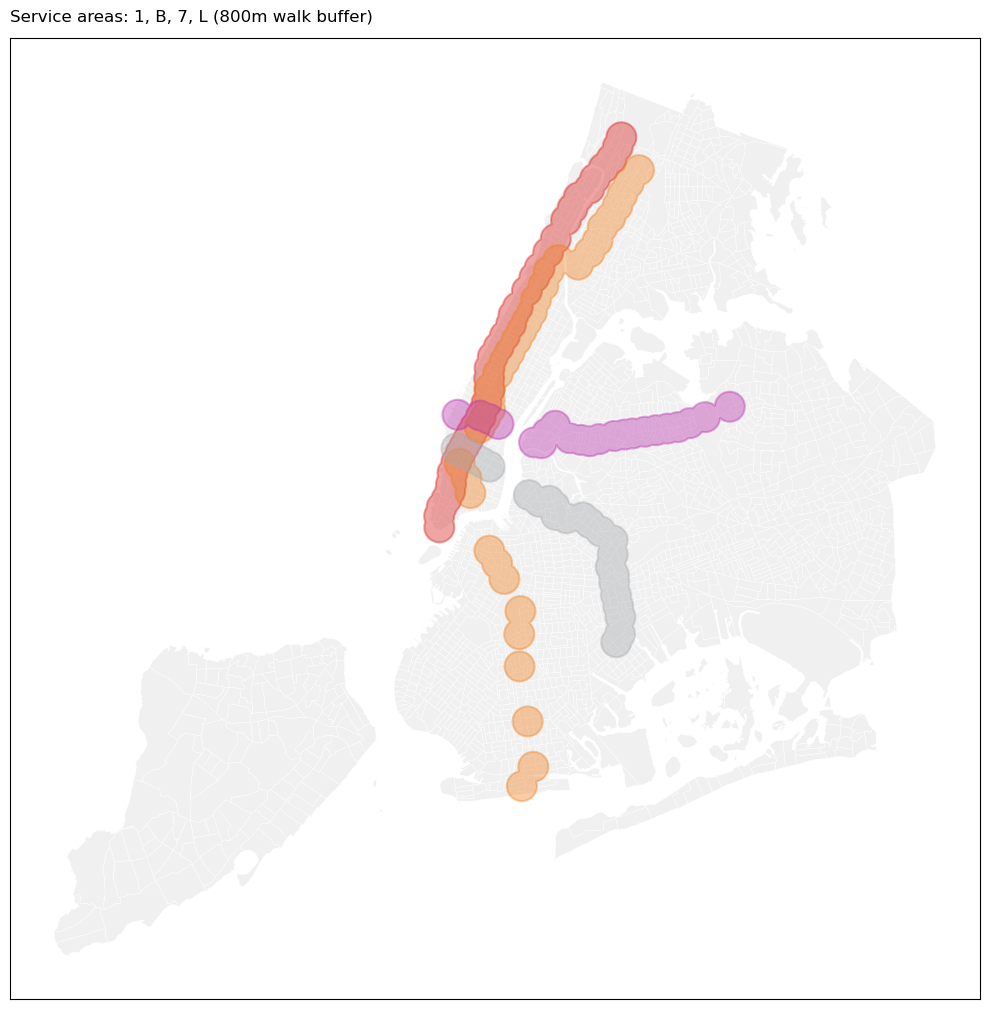

In [6]:
fig, ax = plt.subplots(figsize=(10, 12))
tracts.to_crs(epsg=2263).plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.3)

for line in ["1", "B", "7", "L"]:
    if line in line_service.index:
        line_service.loc[[line]].plot(
            ax=ax,
            color=MTA_COLORS[line],
            alpha=0.4,
            edgecolor=MTA_COLORS[line],
            linewidth=1.5,
        )

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Service areas: 1, B, 7, L (800m walk buffer)",
             loc="left", pad=12)
plt.tight_layout()
plt.show()

In [8]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

YEAR = 2022
NYC_COUNTY_FIPS = ["005", "047", "061", "081", "085"]

session = requests.Session()
retry = Retry(total=5, backoff_factor=2, status_forcelist=[500, 502, 503, 504])
session.mount("https://", HTTPAdapter(max_retries=retry))

records = []
for county in NYC_COUNTY_FIPS:
    url = (
        "https://api.census.gov/data/2022/acs/acs5"
        "?get=NAME,B19013_001E,B25044_003E,B25044_010E,B08301_001E,B08301_010E"
        f"&for=tract:*&in=state:36+county:{county}"
    )
    print(f"fetching county {county}...")
    r = session.get(url, timeout=120)
    r.raise_for_status()
    rows = r.json()
    header, *data = rows
    records.extend(data)
    print(f"  got {len(data)} tracts")

acs = pd.DataFrame(records, columns=header)
print("\ntotal:", acs.shape)
acs.head(3)

fetching county 005...
  got 361 tracts
fetching county 047...
  got 805 tracts
fetching county 061...
  got 310 tracts
fetching county 081...
  got 725 tracts
fetching county 085...
  got 126 tracts

total: (2327, 9)


,NAME,B19013_001E,B25044_003E,B25044_010E,B08301_001E,B08301_010E,state,county,tract
0,Census Tract 1; Bronx County; New York,-666666666,0,0,0,0,36,005,000100
1,Census Tract 2; Bronx County; New York,115064,73,228,2312,843,36,005,000200
2,Census Tract 4; Bronx County; New York,100553,119,481,3140,959,36,005,000400


In [9]:
acs_clean = acs.copy()

numeric_cols = ["B19013_001E", "B25044_003E", "B25044_010E",
                "B08301_001E", "B08301_010E"]
for col in numeric_cols:
    acs_clean[col] = pd.to_numeric(acs_clean[col], errors="coerce")
    acs_clean.loc[acs_clean[col] < 0, col] = pd.NA

acs_clean["geoid"] = acs_clean["state"] + acs_clean["county"] + acs_clean["tract"]

acs_clean = acs_clean.rename(columns={
    "B19013_001E": "median_income",
    "B25044_003E": "owner_no_vehicle",
    "B25044_010E": "renter_no_vehicle",
    "B08301_001E": "commuters_total",
    "B08301_010E": "commuters_transit",
})

acs_clean["no_vehicle"] = acs_clean["owner_no_vehicle"] + acs_clean["renter_no_vehicle"]
acs_clean["transit_share"] = acs_clean["commuters_transit"] / acs_clean["commuters_total"]

print(acs_clean.shape)
print("\nmedian_income missing:", acs_clean["median_income"].isna().sum())
print("median_income median:", int(acs_clean["median_income"].median()))
print("transit_share median:", round(acs_clean["transit_share"].median(), 3))

(2327, 12)

median_income missing: 126
median_income median: 78750
transit_share median: 0.469


In [10]:
print(tracts.columns.tolist())
print(tracts.head(2))

['ctlabel', 'borocode', 'boroname', 'ct2020', 'boroct2020', 'cdeligibil', 'ntaname', 'nta2020', 'cdta2020', 'cdtaname', 'geoid', 'shape_leng', 'shape_area', 'geometry']
  ctlabel borocode   boroname  ct2020 boroct2020 cdeligibil  \
0       1        1  Manhattan  000100    1000100          I   
1   22.01        1  Manhattan  002201    1002201          E   

                                             ntaname nta2020 cdta2020  \
0  The Battery-Governors Island-Ellis Island-Libe...  MN0191     MN01   
1                                    Lower East Side  MN0302     MN03   

                                            cdtaname        geoid  \
0  MN01 Financial District-Tribeca (CD 1 Equivalent)  36061000100   
1   MN03 Lower East Side-Chinatown (CD 3 Equivalent)  36061002201   

     shape_leng    shape_area  \
0  10833.043929  1.843005e+06   
1   5779.062607  1.740174e+06   

                                            geometry  
0  MULTIPOLYGON (((-74.04388 40.69019, -74.04351 ...  
1  

In [11]:
tracts_full = tracts.merge(
    acs_clean[["geoid", "median_income", "transit_share", "commuters_total"]],
    on="geoid",
    how="left",
)
tracts_full = tracts_full.to_crs(epsg=2263)

print("tracts:", tracts_full.shape)
print("with income:", tracts_full["median_income"].notna().sum())

tracts: (2325, 17)
with income: 2201


In [12]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

tracts_full["tract_area"] = tracts_full.geometry.area

line_service_reset = line_service.reset_index()

intersections = gpd.overlay(
    line_service_reset,
    tracts_full[["geoid", "median_income", "transit_share",
                 "commuters_total", "tract_area", "geometry"]],
    how="intersection",
)
intersections["overlap_share"] = intersections.geometry.area / intersections["tract_area"]

print(intersections.shape)
print(intersections[["line", "geoid", "overlap_share", "median_income"]].head())

(6883, 8)
  line        geoid  overlap_share  median_income
0    1  36061004100       0.292416       100096.0
1    1  36061004300       0.185579        97133.0
2    1  36061005400       1.000000       152018.0
3    1  36061005501       0.818093       190408.0
4    1  36061005502       0.001764       138854.0


In [13]:
intersections["weight"] = intersections["overlap_share"] * intersections["commuters_total"]

line_demographics = (
    intersections
    .dropna(subset=["median_income", "weight"])
    .assign(weighted_income=lambda d: d["median_income"] * d["weight"],
            weighted_transit=lambda d: d["transit_share"] * d["weight"])
    .groupby("line")
    .agg(
        total_weight=("weight", "sum"),
        weighted_income_sum=("weighted_income", "sum"),
        weighted_transit_sum=("weighted_transit", "sum"),
    )
    .assign(
        avg_income=lambda d: d["weighted_income_sum"] / d["total_weight"],
        avg_transit_share=lambda d: d["weighted_transit_sum"] / d["total_weight"],
    )
    [["avg_income", "avg_transit_share"]]
    .sort_values("avg_income")
)
line_demographics.round(0)

,avg_income,avg_transit_share
line,,
D,87877.0,1.0
JZ,91953.0,1.0
7,93520.0,1.0
B,94571.0,1.0
5,100899.0,1.0
M,104426.0,0.0
2,106067.0,1.0
4,107087.0,1.0
A,107219.0,1.0


In [14]:
print(acs_clean["transit_share"].describe())
print()
print(acs_clean["transit_share"].head(10))

count    2237.000000
mean        0.462889
std         0.159795
min         0.000000
25%         0.355456
50%         0.469456
75%         0.579292
max         1.000000
Name: transit_share, dtype: float64

0         NaN
1    0.364619
2    0.305414
3    0.442493
4    0.552655
5    0.524631
6         NaN
7         NaN
8    0.645136
9    0.558376
Name: transit_share, dtype: float64


In [15]:
print(intersections[intersections["line"] == "1"]["transit_share"].describe())
print()
print(intersections[intersections["line"] == "1"]["transit_share"].head(10))

count    186.000000
mean       0.489525
std        0.150593
min        0.089041
25%        0.387343
50%        0.485669
75%        0.593865
max        1.000000
Name: transit_share, dtype: float64

0    0.390320
1    0.438277
2    0.513324
3    0.246444
4    0.387127
5    0.431856
6    0.407780
7    0.470573
8    0.512998
9    0.509165
Name: transit_share, dtype: float64


In [17]:
df_cjm = pd.read_csv(RAW / "cjm_2015_present.csv", parse_dates=["month"])
df_cjm.columns = (
    df_cjm.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)
df_cjm = df_cjm[df_cjm["line"].isin(MAIN_LINES) & (df_cjm["line"] != "S 42nd")]
df_cjm["year"] = df_cjm["month"].dt.year

cjtp_peak_by_line = (
    df_cjm[(df_cjm["year"] >= 2022) & (df_cjm["period"] == "peak")]
    .groupby("line")["customer_journey_time_performance"]
    .mean()
    .rename("cjtp_peak")
)

print(cjtp_peak_by_line.round(3).sort_values())

line
B     0.775
Q     0.796
D     0.796
M     0.806
G     0.817
JZ    0.819
N     0.824
C     0.824
R     0.829
A     0.841
F     0.842
E     0.870
2     0.872
5     0.881
6     0.881
4     0.883
3     0.891
W     0.899
1     0.900
7     0.905
L     0.923
Name: cjtp_peak, dtype: float64


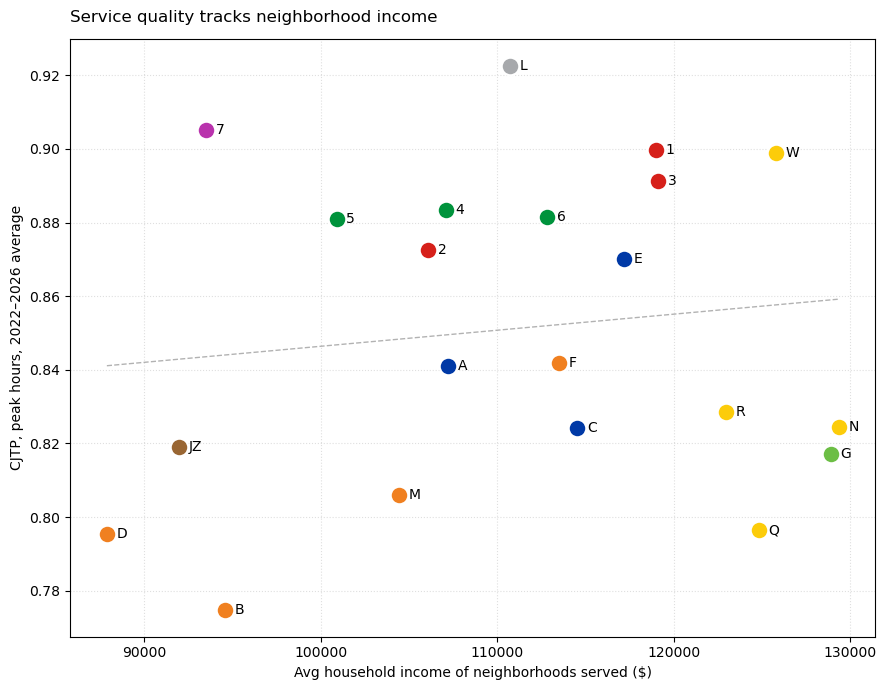

Pearson r = 0.127


In [18]:
plot_data = (
    line_demographics
    .merge(cjtp_peak_by_line, left_index=True, right_index=True)
    .reset_index()
    [["line", "avg_income", "cjtp_peak"]]
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 7))

for _, row in plot_data.iterrows():
    line = row["line"]
    color = MTA_COLORS.get(line, "gray")
    ax.scatter(row["avg_income"], row["cjtp_peak"],
               s=160, color=color, edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate(line, (row["avg_income"], row["cjtp_peak"]),
                xytext=(7, 0), textcoords="offset points",
                fontsize=10, va="center")

import numpy as np
x = plot_data["avg_income"].values
y = plot_data["cjtp_peak"].values
slope, intercept = np.polyfit(x, y, 1)
xs = np.array([x.min(), x.max()])
ax.plot(xs, slope * xs + intercept, color="gray", linestyle="--",
        linewidth=1, alpha=0.6, zorder=1)

ax.set_xlabel("Avg household income of neighborhoods served ($)")
ax.set_ylabel("CJTP, peak hours, 2022–2026 average")
ax.set_title("Service quality tracks neighborhood income",
             loc="left", pad=12)
ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

correlation = np.corrcoef(x, y)[0, 1]
print(f"Pearson r = {correlation:.3f}")

In [19]:
fig.savefig(FIGURES / "04_income_vs_cjtp_wip.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURES / "04_income_vs_cjtp_wip.pdf", bbox_inches="tight")